In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import json
import random

random.seed(42)

# TR_Commands.xlsx oku
try:
    df_excel = pd.read_excel("TR_Commands.xlsx")
    temel_komutlar = df_excel['Command'].dropna().tolist()
    print(f"✅ TR_Commands.xlsx okundu. {len(temel_komutlar)} temel komut bulundu.")
except FileNotFoundError:
    print("UYARI: TR_Commands.xlsx bulunamadı. Yedek komutlar kullanılıyor.")
    temel_komutlar = ["ışığı aç", "ışığı kapa", "klimayı aç", "klimayı kapa",
                      "TV aç", "TV kapa", "panjuru aç", "perdeyi kapat"]

# ================================================
# INTENT KURALLARI — hangi kelime hangi servise gider
# ================================================
intent_rules = [
    {
        "service": "light.turn_on",
        "entity_id": "light.living_room",
        "keywords": ["ışığ", "aydınlatma", "lamba", "ampul", "kırmızı ışığ", "mavi ışığ", "yeşil ışığ"],
        "actions": ["aç", "yak", "aktif et", "çalıştır", "devreye al"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "bana {k} {a} mısın",
            "şimdi {k} {a}",
            "biraz {k} {a} olur mu",
            "ev {k} {a} olsun",
            "{k} {a} istiyorum",
            "odadaki {k} {a}",
            "hemen {k} {a}",
            "{k} açık olsun",
        ]
    },
    {
        "service": "light.turn_off",
        "entity_id": "light.living_room",
        "keywords": ["ışığ", "aydınlatma", "lamba", "ampul", "kırmızı ışığ", "mavi ışığ", "yeşil ışığ"],
        "actions": ["kapa", "kapat", "söndür", "kes", "devre dışı bırak"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "bana {k} {a} mısın",
            "{k} {a} istiyorum",
            "odadaki {k} {a}",
            "hemen {k} {a}",
            "{k} kapalı olsun",
            "artık {k} gerek yok",
            "{k} istemiyorum",
            "çok parlak {k} {a}",
        ]
    },
    {
        "service": "light.set_brightness",
        "entity_id": "light.living_room",
        "keywords": ["ışığ", "aydınlatma", "parlaklığ"],
        "actions": ["kıs", "arttır", "azalt", "düşür", "ayarla"],
        "templates": [
            "{k} {a}",
            "{k} biraz {a}",
            "lütfen {k} {a}",
            "{k} daha fazla {a}",
            "{k} daha az {a}",
            "göz alıyor {k} {a}",
            "karanlık {k} {a}",
            "ortam için {k} {a}",
            "{k} seviyesini {a}",
            "romantik için {k} {a}",
        ]
    },
    {
        "service": "climate.turn_on",
        "entity_id": "climate.living_room",
        "keywords": ["klimay", "ısıtmay", "iklimlendirmey", "kombiy", "ısıt", "fanı"],
        "actions": ["aç", "çalıştır", "aktif et", "devreye al", "başlat"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "hava çok soğuk {k} {a}",
            "üşüdüm {k} {a}",
            "evi ısıt",
            "odayı ısıt",
            "içerisi soğuk {k} {a}",
            "hemen {k} {a}",
            "{k} açık olsun",
        ]
    },
    {
        "service": "climate.turn_off",
        "entity_id": "climate.living_room",
        "keywords": ["klimay", "ısıtmay", "iklimlendirmey", "kombiy", "fanı"],
        "actions": ["kapa", "kapat", "durdur", "kes", "devre dışı bırak"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "hava yeterince ısındı {k} {a}",
            "çok sıcak oldu {k} {a}",
            "{k} kapalı olsun",
            "artık {k} gerek yok",
            "hemen {k} {a}",
            "yeter artık {k} {a}",
            "enerji tasarrufu için {k} {a}",
        ]
    },
    {
        "service": "climate.set_temperature",
        "entity_id": "climate.living_room",
        "keywords": ["sıcaklığ", "ısıyı", "dereceyi", "temperatürü"],
        "actions": ["arttır", "düşür", "azalt", "ayarla", "değiştir"],
        "templates": [
            "{k} {a}",
            "{k} biraz {a}",
            "lütfen {k} {a}",
            "çok sıcak {k} {a}",
            "çok soğuk {k} {a}",
            "daha konforlu için {k} {a}",
            "22 derece yap",
            "sıcaklığı 20'ye ayarla",
            "evi soğut",
            "biraz daha serin olsun",
        ]
    },
    {
        "service": "media_player.turn_on",
        "entity_id": "media_player.tv",
        "keywords": ["TV", "televizyonu", "multimedyay", "müziği", "müzik aç"],
        "actions": ["aç", "çalıştır", "aktif et", "başlat", "devreye al"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "film izlemek istiyorum {k} {a}",
            "haber izleyeyim {k} {a}",
            "eğlence için {k} {a}",
            "biraz {k} {a}",
            "hemen {k} {a}",
            "{k} açık olsun",
            "akşam için {k} {a}",
        ]
    },
    {
        "service": "media_player.turn_off",
        "entity_id": "media_player.tv",
        "keywords": ["TV", "televizyonu", "multimedyay", "müziği"],
        "actions": ["kapa", "kapat", "durdur", "kes", "kapat artık"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "uyuyacağım {k} {a}",
            "çok gürültülü {k} {a}",
            "artık {k} gerek yok",
            "hemen {k} {a}",
            "{k} kapalı olsun",
            "yeter artık {k} {a}",
            "sessizlik istiyorum {k} {a}",
        ]
    },
    {
        "service": "media_player.media_pause",
        "entity_id": "media_player.spotify",
        "keywords": ["müziği", "şarkıyı", "videoyu", "yayını"],
        "actions": ["durdur", "poz ver", "beklet", "duraklat", "sus"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "bir dakika {k} {a}",
            "telefon açıyorum {k} {a}",
            "biraz {k} {a}",
            "şimdi {k} {a}",
            "{k} şu an {a}",
            "beklet biraz",
            "sonra devam ederim {k} {a}",
            "müziği kes",
        ]
    },
    {
        "service": "cover.open_cover",
        "entity_id": "cover.living_room_blinds",
        "keywords": ["panjuru", "perdeyi", "jalusiyi", "stor perdeyi"],
        "actions": ["aç", "kaldır", "yukarı çek", "aç biraz", "tamamen aç"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "güneş girsin {k} {a}",
            "hava almak için {k} {a}",
            "aydınlık olsun {k} {a}",
            "sabah oldu {k} {a}",
            "içerisi karanlık {k} {a}",
            "manzarayı görmek istiyorum {k} {a}",
            "hemen {k} {a}",
        ]
    },
    {
        "service": "cover.close_cover",
        "entity_id": "cover.living_room_blinds",
        "keywords": ["panjuru", "perdeyi", "jalusiyi", "stor perdeyi"],
        "actions": ["kapa", "kapat", "indir", "aşağı indir", "tamamen kapat"],
        "templates": [
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} {a} istiyorum",
            "güneş çok vuruyor {k} {a}",
            "gizlilik için {k} {a}",
            "film izleyeceğim {k} {a}",
            "uyumak için {k} {a}",
            "dışarıdan görünmesin {k} {a}",
            "serin olsun {k} {a}",
            "hemen {k} {a}",
        ]
    },
    {
        "service": "scene.turn_on",
        "entity_id": "scene.movie_time",
        "keywords": ["film zamanı", "uyku zamanı", "parti zamanı", "çalışma zamanı",
                     "dinlenme zamanı", "spor zamanı", "eve geliyorum", "evden çıkıyorum"],
        "actions": ["başlat", "aktif et", "aç", "devreye al", ""],
        "templates": [
            "{k}",
            "{k} {a}",
            "lütfen {k} {a}",
            "{k} moduna geç",
            "{k} ayarlarını aç",
            "şimdi {k}",
            "{k} vakti",
            "hadi {k}",
            "{k} senaryosunu başlat",
            "{k} için hazırlık yap",
        ]
    },
]

# ================================================
# VERİ ÜRET
# ================================================
dataset = []

for rule in intent_rules:
    komutlar = set()
    # Şablonlardan üret
    for keyword in rule["keywords"]:
        for action in rule["actions"]:
            for template in rule["templates"]:
                try:
                    cmd = template.format(k=keyword, a=action).strip()
                    cmd = " ".join(cmd.split())  # fazla boşlukları temizle
                    if len(cmd) > 3:
                        komutlar.add(cmd)
                except:
                    pass

    # TR_Commands.xlsx'ten eşleşen komutları da ekle
    for base_cmd in temel_komutlar:
        base_lower = base_cmd.lower()
        for keyword in rule["keywords"]:
            kw_lower = keyword.lower().rstrip("ğüşıöç")  # kök eşleşmesi
            if kw_lower[:4] in base_lower or base_lower in keyword.lower():
                komutlar.add(base_cmd)
                break

    komutlar = list(komutlar)
    print(f"  ✅ {rule['service']} → {len(komutlar)} komut")

    for cmd in komutlar:
        dataset.append({
            "instruction": cmd,
            "output": json.dumps({
                "service": rule["service"],
                "entity_id": rule["entity_id"]
            }, ensure_ascii=False)
        })

# ================================================
# KAYDET
# ================================================
df = pd.DataFrame(dataset).drop_duplicates(subset=["instruction"])
print(f"\nToplam: {len(df)} benzersiz örnek")

try:
    train_df, test_df = train_test_split(
        df, test_size=0.2, random_state=42,
        stratify=df['output'].apply(lambda x: json.loads(x)['service'])
    )
except ValueError:
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.to_json("train_dataset.jsonl", orient="records", lines=True, force_ascii=False)
test_df.to_json("test_dataset.jsonl",   orient="records", lines=True, force_ascii=False)

print(f"🎉 Veri seti hazır! Eğitim: {len(train_df)} | Test: {len(test_df)}")
print(f"\nIntent dağılımı:\n{df['output'].apply(lambda x: json.loads(x)['service']).value_counts().to_string()}")

UYARI: TR_Commands.xlsx bulunamadı. Yedek komutlar kullanılıyor.
  ✅ light.turn_on → 330 komut
  ✅ light.turn_off → 274 komut
  ✅ light.set_brightness → 158 komut
  ✅ climate.turn_on → 220 komut
  ✅ climate.turn_off → 212 komut
  ✅ climate.set_temperature → 124 komut
  ✅ media_player.turn_on → 231 komut
  ✅ media_player.turn_off → 169 komut
  ✅ media_player.media_pause → 162 komut
  ✅ cover.open_cover → 201 komut
  ✅ cover.close_cover → 201 komut
  ✅ scene.turn_on → 136 komut

Toplam: 2387 benzersiz örnek
🎉 Veri seti hazır! Eğitim: 1909 | Test: 478

Intent dağılımı:
output
light.turn_on               330
light.turn_off              266
media_player.turn_on        229
climate.turn_on             218
climate.turn_off            210
cover.close_cover           199
cover.open_cover            199
media_player.turn_off       167
media_player.media_pause    159
light.set_brightness        150
scene.turn_on               136
climate.set_temperature     124


In [2]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

shutil.copy("train_dataset.jsonl", "/content/drive/MyDrive/train_dataset.jsonl")
shutil.copy("test_dataset.jsonl",  "/content/drive/MyDrive/test_dataset.jsonl")

print("✅ Drive'a kaydedildi!")

Mounted at /content/drive
✅ Drive'a kaydedildi!


In [ ]:
!pip install -q transformers==4.46.1 trl==0.11.4 peft bitsandbytes accelerate datasets

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from google.colab import userdata

hf_token   = userdata.get('HF_TOKEN')
model_name = "google/gemma-2b-it"
print(f"📥 {model_name} yükleniyor...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token
)

dataset = load_dataset("json", data_files={"train": "train_dataset.jsonl", "test": "test_dataset.jsonl"})

def format_prompts(examples):
    texts = []
    for instruction, output in zip(examples['instruction'], examples['output']):
        text = (f"Aşağıdaki komutu Home Assistant JSON formatına çevir.\n"
                f"Komut: {instruction}\n"
                f"Çıktı: {output}{tokenizer.eos_token}")
        texts.append(text)
    return {"text": texts}

formatted_dataset = dataset.map(format_prompts, batched=True)

peft_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./home_llm_gemma_finetuned",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=5,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=256,
    tokenizer=tokenizer,
    args=training_args,
)

print("🚀 Gemma fine-tuning başlıyor...")
trainer.train()

trainer.model.save_pretrained("home_llm_gemma_lora")
tokenizer.save_pretrained("home_llm_gemma_lora")
print("✅ Gemma modeli kaydedildi → home_llm_gemma_lora/")

📥 google/gemma-2b-it yükleniyor...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [google.genai, mcp] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Epoch,Training Loss,Validation Loss
0,0.239100,0.224568
1,0.184800,0.189954
2,0.171700,0.177709


✅ Gemma modeli kaydedildi → home_llm_gemma_lora/


In [ ]:
!pip install -q transformers==4.46.1 trl==0.11.4 peft bitsandbytes accelerate datasets

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer
from google.colab import userdata

hf_token   = userdata.get('HF_TOKEN')
model_name = "meta-llama/Llama-3.2-3B-Instruct"   # 3B Colab T4'te sığar
print(f"📥 {model_name} yükleniyor...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token
)

dataset = load_dataset("json", data_files={"train": "train_dataset.jsonl", "test": "test_dataset.jsonl"})

def format_prompts(examples):
    texts = []
    for instruction, output in zip(examples['instruction'], examples['output']):
        # LLaMA chat formatı
        text = (f"<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n"
                f"Aşağıdaki komutu Home Assistant JSON formatına çevir.\n"
                f"Komut: {instruction}<|eot_id|>"
                f"<|start_header_id|>assistant<|end_header_id|>\n"
                f"{output}<|eot_id|>")
        texts.append(text)
    return {"text": texts}

formatted_dataset = dataset.map(format_prompts, batched=True)

peft_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./home_llm_llama_finetuned",
    per_device_train_batch_size=2,        # LLaMA için daha düşük batch
    gradient_accumulation_steps=8,
    optim="paged_adamw_32bit",
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=5,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=256,
    tokenizer=tokenizer,
    args=training_args,
)

print("🚀 LLaMA 3.2 fine-tuning başlıyor...")
trainer.train()

trainer.model.save_pretrained("home_llm_llama_lora")
tokenizer.save_pretrained("home_llm_llama_lora")
print("✅ LLaMA modeli kaydedildi → home_llm_llama_lora/")

📥 meta-llama/Llama-3.2-3B-Instruct yükleniyor...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

...

Map:   0%|          | 0/487 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:401: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  super().__init__(


🚀 LLaMA 3.2 fine-tuning başlıyor...


Epoch,Training Loss,Validation Loss
0,0.454500,0.400805
1,0.208300,0.220947
2,0.200000,0.208130


✅ LLaMA modeli kaydedildi → home_llm_llama_lora/


In [ ]:
!pip install --upgrade torchao peft
import torch
import json
import time
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ================================================
# PROMPT TEMPLATES
# ================================================
def get_prompt_llama(prompt_type, instruction):
    if prompt_type == "zero_shot":
        system = "Türkçe akıllı ev komutlarını Home Assistant JSON formatına çevir. Sadece JSON çıktısı ver."
        user   = f"Komut: {instruction}"
    elif prompt_type == "few_shot":
        system = "Türkçe akıllı ev komutlarını Home Assistant JSON formatına çevir. Sadece JSON çıktısı ver."
        user   = (f'Örnek 1: Komut: Işığı aç → {{"service": "light.turn_on", "entity_id": "light.living_room"}}\n'
                  f'Örnek 2: Komut: Klimayı kapat → {{"service": "climate.turn_off", "entity_id": "climate.living_room"}}\n'
                  f'Örnek 3: Komut: Perdeyi indir → {{"service": "cover.close_cover", "entity_id": "cover.living_room_blinds"}}\n'
                  f"Komut: {instruction}")
    elif prompt_type == "role_play":
        system = "Sen bir akıllı ev asistanısın. Türkçe komutları Home Assistant JSON formatına çevirirsin. Sadece JSON yaz."
        user   = f"Komut: {instruction}"
    return system, user

# ================================================
# PARSE OUTPUT
# ================================================
def parse_service(text):
    try:
        start = text.find('{')
        end   = text.rfind('}') + 1
        if start != -1 and end > start:
            j = json.loads(text[start:end])
            return j.get('service', 'unknown'), True
    except:
        pass
    return 'invalid_json', False

# ================================================
# EVALUATION
# ================================================
def evaluate_llama(model, tokenizer, test_df, prompt_type):
    y_true, y_pred, latencies = [], [], []
    valid_json_count = 0

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), leave=False):
        instruction      = row['instruction']
        expected_service = json.loads(row['output'])['service']
        system, user     = get_prompt_llama(prompt_type, instruction)

        messages = [{"role": "system", "content": system},
                    {"role": "user",   "content": user}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
        t0 = time.time()

        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=60, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

        latencies.append(time.time() - t0)

        response = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        pred, valid = parse_service(response)

        if valid:
            valid_json_count += 1

        y_true.append(expected_service)
        y_pred.append(pred)

    return _compute_metrics(y_true, y_pred, valid_json_count, latencies, len(test_df))

def _compute_metrics(y_true, y_pred, valid_json_count, latencies, n):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        "Accuracy":        round(acc, 4),
        "Precision":       round(p, 4),
        "Recall":          round(r, 4),
        "F1":              round(f1, 4),
        "Valid JSON Rate": round(valid_json_count / n, 4),
        "Avg Latency (s)": round(sum(latencies) / len(latencies), 3),
    }

# ================================================
# MAIN EXECUTION
# ================================================
try:
    test_df = pd.read_json("test_dataset.jsonl", lines=True)
    print(f"Test set loaded: {len(test_df)} samples\n")
except FileNotFoundError:
    print("Error: test_dataset.jsonl not found in the current environment.")

all_results = {}

print("=" * 50)
print("📊 Evaluating LLaMA 3.2 Fine-tuned")
print("=" * 50)

# IMPORTANT: PASTE YOUR HF TOKEN HERE
HF_TOKEN = "YOUR TOKEN"

# Paths dynamically reading from My Drive
LORA_PATH = "/content/drive/MyDrive/home_llm_llama_lora"
CSV_SAVE_PATH = "/content/drive/MyDrive/llama_results.csv"

try:
    llama_tok = AutoTokenizer.from_pretrained(LORA_PATH)
    llama_base = AutoModelForCausalLM.from_pretrained(
        "meta-llama/Llama-3.2-3B-Instruct", device_map="auto",
        torch_dtype=torch.bfloat16, token=HF_TOKEN
    )
    llama_model = PeftModel.from_pretrained(llama_base, LORA_PATH)
    llama_model.eval()

    print(f"⚡ Starting evaluation...\n")

    llama_results = {}
    for pt in ["zero_shot", "few_shot", "role_play"]:
        print(f"  [{pt.upper()}] Testing...")
        m = evaluate_llama(llama_model, llama_tok, test_df, pt)
        llama_results[pt] = m
        print(f"  ✅ Acc:{m['Accuracy']} F1:{m['F1']} JSON:{m['Valid JSON Rate']} Lat:{m['Avg Latency (s)']}s\n")

    all_results["LLaMA (Fine-tuned)"] = llama_results

    # Free up memory
    del llama_model, llama_base
    torch.cuda.empty_cache()

    rows = []
    for model_label, prompt_results in all_results.items():
        for prompt_type, metrics in prompt_results.items():
            rows.append({"Model": model_label, "Prompt": prompt_type, **metrics})

    df = pd.DataFrame(rows)
    df.to_csv(CSV_SAVE_PATH, index=False)

    print(f"\n✅ Results successfully saved directly to your Drive: {CSV_SAVE_PATH}")
    print("\n" + df.to_markdown(index=False))

except Exception as e:
    print(f"Error loading model from Drive: {e}")
    print("Ensure 'home_llm_llama_lora' folder is placed directly in your 'My Drive' root.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test set loaded: 478 samples

📊 Evaluating LLaMA 3.2 Fine-tuned


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

⚡ Starting evaluation...

  [ZERO_SHOT] Testing...


  0%|          | 0/478 [00:00<?, ?it/s][transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  ✅ Acc:0.9686 F1:0.9798 JSON:0.977 Lat:1.07s

  [FEW_SHOT] Testing...


  ✅ Acc:0.9289 F1:0.9216 JSON:1.0 Lat:1.072s

  [ROLE_PLAY] Testing...


  ✅ Acc:0.9728 F1:0.9813 JSON:0.9854 Lat:1.064s


✅ Results successfully saved directly to your Drive: /content/drive/MyDrive/llama_results.csv

| Model              | Prompt    |   Accuracy |   Precision |   Recall |     F1 |   Valid JSON Rate |   Avg Latency (s) |
|:-------------------|:----------|-----------:|------------:|---------:|-------:|------------------:|------------------:|
| LLaMA (Fine-tuned) | zero_shot |     0.9686 |      0.9958 |   0.9686 | 0.9798 |            0.977  |             1.07  |
| LLaMA (Fine-tuned) | few_shot  |     0.9289 |      0.9502 |   0.9289 | 0.9216 |            1      |             1.072 |
| LLaMA (Fine-tuned) | role_play |     0.9728 |      0.9912 |   0.9728 | 0.9813 |            0.9854 |             1.064 |


In [ ]:
!pip install --upgrade torchao peft
import torch
import json
import time
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from google.colab import drive

# Google Drive'ı Bağla
drive.mount('/content/drive')

# ================================================
# GEMMA PROMPT ŞABLONLARI
# ================================================
def get_prompt_gemma(prompt_type, instruction):
    if prompt_type == "zero_shot":
        return (f"Aşağıdaki komutu Home Assistant JSON formatına çevir.\n"
                f"Komut: {instruction}\nÇıktı:")
    elif prompt_type == "few_shot":
        return (f"Aşağıdaki komutu Home Assistant JSON formatına çevir.\n\n"
                f'Örnek 1:\nKomut: Mutfak ışıklarını aç\nÇıktı: {{"service": "light.turn_on", "entity_id": "light.living_room"}}\n\n'
                f'Örnek 2:\nKomut: Klimayı kapat\nÇıktı: {{"service": "climate.turn_off", "entity_id": "climate.living_room"}}\n\n'
                f'Örnek 3:\nKomut: Perdeyi indir\nÇıktı: {{"service": "cover.close_cover", "entity_id": "cover.living_room_blinds"}}\n\n'
                f"Komut: {instruction}\nÇıktı:")
    elif prompt_type == "role_play":
        return (f"Sen akıllı bir Home Assistant sistemisin. Türkçe komutları JSON servis çağrısına dönüştürürsün. Sadece geçerli JSON üret.\n"
                f"Komut: {instruction}\nÇıktı:")

# ================================================
# ÇIKTIYI AYRIŞTIR (PARSE)
# ================================================
def parse_service(text):
    try:
        start = text.find('{')
        end   = text.rfind('}') + 1
        if start != -1 and end > start:
            j = json.loads(text[start:end])
            return j.get('service', 'unknown'), True
    except:
        pass
    return 'invalid_json', False

# ================================================
# GEMMA DEĞERLENDİRME FONKSİYONU
# ================================================
def evaluate_gemma(model, tokenizer, test_df, prompt_type):
    y_true, y_pred, latencies = [], [], []
    valid_json_count = 0

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), leave=False):
        instruction      = row['instruction']
        expected_service = json.loads(row['output'])['service']
        prompt           = get_prompt_gemma(prompt_type, instruction)

        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
        t0 = time.time()

        with torch.no_grad():
            out = model.generate(
                **inputs, max_new_tokens=60, do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

        latencies.append(time.time() - t0)

        # Sadece modelin yeni ürettiği kısmı al (input'u atla)
        response = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        pred, valid = parse_service(response)

        if valid:
            valid_json_count += 1

        y_true.append(expected_service)
        y_pred.append(pred)

    return _compute_metrics(y_true, y_pred, valid_json_count, latencies, len(test_df))

def _compute_metrics(y_true, y_pred, valid_json_count, latencies, n):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {
        "Accuracy":        round(acc, 4),
        "Precision":       round(p, 4),
        "Recall":          round(r, 4),
        "F1":              round(f1, 4),
        "Valid JSON Rate": round(valid_json_count / n, 4),
        "Avg Latency (s)": round(sum(latencies) / len(latencies), 3),
    }

# ================================================
# ANA ÇALIŞTIRMA BLOĞU
# ================================================
try:
    test_df = pd.read_json("test_dataset.jsonl", lines=True)
    print(f"Test seti yüklendi: {len(test_df)} örnek\n")
except FileNotFoundError:
    print("HATA: test_dataset.jsonl dosyası bulunamadı.")

all_results = {}

print("=" * 50)
print("📊 Gemma Fine-tuned Testi Başlıyor")
print("=" * 50)

# Senin HF Token'ın
HF_TOKEN = ""

# Drive üzerindeki yollar (Gemma için güncellendi)
LORA_PATH = "/content/drive/MyDrive/home_llm_gemma_lora"
CSV_SAVE_PATH = "/content/drive/MyDrive/gemma_results.csv"

try:
    gemma_tok = AutoTokenizer.from_pretrained(LORA_PATH)
    gemma_base = AutoModelForCausalLM.from_pretrained(
        "google/gemma-2b-it", device_map="auto",
        torch_dtype=torch.bfloat16, token=HF_TOKEN
    )
    gemma_model = PeftModel.from_pretrained(gemma_base, LORA_PATH)
    gemma_model.eval()

    print(f"⚡ Değerlendirme başlıyor...\n")

    gemma_results = {}
    for pt in ["zero_shot", "few_shot", "role_play"]:
        print(f"  [{pt.upper()}] Test ediliyor...")
        m = evaluate_gemma(gemma_model, gemma_tok, test_df, pt)
        gemma_results[pt] = m
        print(f"  ✅ Acc:{m['Accuracy']} F1:{m['F1']} JSON:{m['Valid JSON Rate']} Lat:{m['Avg Latency (s)']}s\n")

    all_results["Gemma (Fine-tuned)"] = gemma_results

    # Belleği temizle
    del gemma_model, gemma_base
    torch.cuda.empty_cache()

    rows = []
    for model_label, prompt_results in all_results.items():
        for prompt_type, metrics in prompt_results.items():
            rows.append({"Model": model_label, "Prompt": prompt_type, **metrics})

    df = pd.DataFrame(rows)
    df.to_csv(CSV_SAVE_PATH, index=False)

    print(f"\n✅ Sonuçlar doğrudan Drive'ına kaydedildi: {CSV_SAVE_PATH}")
    print("\n" + df.to_markdown(index=False))

except Exception as e:
    print(f"Drive'dan model yüklenirken hata oluştu: {e}")
    print("'home_llm_gemma_lora' klasörünün Drive'ının ana dizininde olduğundan emin ol.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test seti yüklendi: 478 örnek

📊 Gemma Fine-tuned Testi Başlıyor


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

⚡ Değerlendirme başlıyor...

  [ZERO_SHOT] Test ediliyor...


  ✅ Acc:0.7531 F1:0.8464 JSON:0.7594 Lat:2.205s

  [FEW_SHOT] Test ediliyor...


  ✅ Acc:0.8891 F1:0.9086 JSON:1.0 Lat:0.957s

  [ROLE_PLAY] Test ediliyor...


  ✅ Acc:0.8954 F1:0.9382 JSON:0.9059 Lat:2.098s


✅ Sonuçlar doğrudan Drive'ına kaydedildi: /content/drive/MyDrive/gemma_results.csv

| Model              | Prompt    |   Accuracy |   Precision |   Recall |     F1 |   Valid JSON Rate |   Avg Latency (s) |
|:-------------------|:----------|-----------:|------------:|---------:|-------:|------------------:|------------------:|
| Gemma (Fine-tuned) | zero_shot |     0.7531 |      0.991  |   0.7531 | 0.8464 |            0.7594 |             2.205 |
| Gemma (Fine-tuned) | few_shot  |     0.8891 |      0.9565 |   0.8891 | 0.9086 |            1      |             0.957 |
| Gemma (Fine-tuned) | role_play |     0.8954 |      0.988  |   0.8954 | 0.9382 |            0.9059 |             2.098 |


In [ ]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

# Dosyaları geri yükle
for f in ["test_dataset.jsonl", "slm_results.csv", "llm_results.csv"]:
    src = f"/content/drive/MyDrive/{f}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/{f}")
        print(f"✅ {f} yüklendi")
    else:
        print(f"⚠️ {f} Drive'da bulunamadı")

Mounted at /content/drive
✅ test_dataset.jsonl yüklendi
⚠️ slm_results.csv Drive'da bulunamadı
⚠️ llm_results.csv Drive'da bulunamadı


In [ ]:
response = client.chat.completions.create(
    messages=[
        {"role": "system", "content": 'Sen bir Home Assistant asistanısın. Sadece şu formatta JSON döndür, başka hiçbir şey yazma: {"service": "...", "entity_id": "..."}'},
        {"role": "user", "content": 'Komutu JSON\'a çevir. Komut: Işığı aç\nSadece JSON yaz:'}
    ],
    model="llama-3.1-8b-instant",
    temperature=0.1,
    max_tokens=60
)
print(repr(response.choices[0].message.content))

'{"service": "light.turn_on", "entity_id": "..." }'


In [ ]:
!pip install -q groq

import os
import json
import time
import pandas as pd
from groq import Groq
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm
from google.colab import userdata

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
client     = Groq()
model_name = "llama-3.1-8b-instant"

test_df = pd.read_json("test_dataset.jsonl", lines=True).sample(n=150, random_state=42)
print(f"Test seti: {len(test_df)} örnek (kısaltıldı) | Model: {model_name}\n")

SYSTEM_PROMPT = ('Sen bir Home Assistant asistanısın. '
                 'Sadece şu formatta JSON döndür, başka hiçbir şey yazma: '
                 '{"service": "...", "entity_id": "..."}')

# ================================================
# PROMPT ŞABLONLARI
# ================================================
def get_messages(prompt_type, instruction):
    if prompt_type == "zero_shot":
        user = f"Komutu JSON'a çevir.\nKomut: {instruction}\nSadece JSON yaz:"

    elif prompt_type == "few_shot":
        user = (f'Örnekler:\n'
                f'Komut: Işığı aç → {{"service": "light.turn_on", "entity_id": "light.living_room"}}\n'
                f'Komut: Klimayı kapat → {{"service": "climate.turn_off", "entity_id": "climate.living_room"}}\n'
                f'Komut: Perdeyi indir → {{"service": "cover.close_cover", "entity_id": "cover.living_room_blinds"}}\n'
                f"Komut: {instruction}\nSadece JSON yaz:")

    elif prompt_type == "role_play":
        user = (f"Akıllı ev sisteminin bir parçasısın. "
                f"Kullanıcı komutunu Home Assistant servisine çevir.\n"
                f"Komut: {instruction}\nSadece JSON yaz:")

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user}
    ]

# ================================================
# GROQ DEĞERLENDİRME
# ================================================
def evaluate_groq(prompt_type):
    print(f"\n[LLM - {model_name}] {prompt_type.upper()} testi başlıyor...")
    y_true, y_pred = [], []
    latencies, valid_json_count, total_tokens = [], 0, 0

    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
        instruction      = row['instruction']
        expected_service = json.loads(row['output'])['service']
        messages         = get_messages(prompt_type, instruction)

        predicted_service = 'api_error'
        for attempt in range(3):
            try:
                t0 = time.time()
                completion = client.chat.completions.create(
                    messages=messages,
                    model=model_name,
                    temperature=0.1,
                    max_tokens=60
                )
                latency = time.time() - t0
                latencies.append(latency)
                response_text  = completion.choices[0].message.content.strip()
                total_tokens  += completion.usage.total_tokens

                # JSON parse
                start = response_text.find('{')
                end   = response_text.rfind('}') + 1
                if start != -1 and end > start:
                    predicted_json    = json.loads(response_text[start:end])
                    predicted_service = predicted_json.get('service', 'unknown')
                    valid_json_count += 1
                else:
                    predicted_service = 'invalid_format'
                break
            except Exception as e:
                if attempt < 2:
                    time.sleep(3)
                else:
                    predicted_service = 'api_error'

        y_true.append(expected_service)
        y_pred.append(predicted_service)
        time.sleep(1.2)  # rate limit

    accuracy  = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0)
    valid_json_rate = valid_json_count / len(test_df)
    avg_latency     = sum(latencies) / len(latencies) if latencies else 0
    avg_tokens      = total_tokens / len(test_df)

    print(f"  ✅ Accuracy: {accuracy:.4f} | F1: {f1:.4f} | "
          f"Valid JSON: {valid_json_rate:.2%} | Latency: {avg_latency:.2f}s | Tokens/req: {avg_tokens:.1f}")

    return {
        "Accuracy":        round(accuracy, 4),
        "Precision":       round(precision, 4),
        "Recall":          round(recall, 4),
        "F1":              round(f1, 4),
        "Valid JSON Rate": round(valid_json_rate, 4),
        "Avg Latency (s)": round(avg_latency, 3),
        "Avg Tokens":      round(avg_tokens, 1),
    }

# ================================================
# TESTLER
# ================================================
llm_results = {}
for p_type in ["zero_shot", "few_shot", "role_play"]:
    llm_results[p_type] = evaluate_groq(p_type)

# ================================================
# KAYDET
# ================================================
rows = [{"Model": "LLaMA-3.1-8B (LLM)", "Prompt": p, **m} for p, m in llm_results.items()]
df_llm = pd.DataFrame(rows)
df_llm.to_csv("llm_results.csv", index=False)

# Drive'a da kaydet
from google.colab import drive
import shutil, os
drive.mount('/content/drive', force_remount=False)
shutil.copy("llm_results.csv", "/content/drive/MyDrive/llm_results.csv")

print("\n✅ llm_results.csv kaydedildi.")
print("\n" + df_llm.to_markdown(index=False))

Test seti: 150 örnek (kısaltıldı) | Model: llama-3.1-8b-instant


[LLM - llama-3.1-8b-instant] ZERO_SHOT testi başlıyor...


100%|██████████| 150/150 [07:46<00:00,  3.11s/it]


  ✅ Accuracy: 0.4267 | F1: 0.4372 | Valid JSON: 98.67% | Latency: 1.78s | Tokens/req: 117.8

[LLM - llama-3.1-8b-instant] FEW_SHOT testi başlıyor...


100%|██████████| 150/150 [08:42<00:00,  3.48s/it]


  ✅ Accuracy: 0.6333 | F1: 0.6472 | Valid JSON: 99.33% | Latency: 2.21s | Tokens/req: 194.8

[LLM - llama-3.1-8b-instant] ROLE_PLAY testi başlıyor...


100%|██████████| 150/150 [08:56<00:00,  3.57s/it]


  ✅ Accuracy: 0.4133 | F1: 0.4051 | Valid JSON: 98.00% | Latency: 2.17s | Tokens/req: 138.7
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ llm_results.csv kaydedildi.

| Model              | Prompt    |   Accuracy |   Precision |   Recall |     F1 |   Valid JSON Rate |   Avg Latency (s) |   Avg Tokens |
|:-------------------|:----------|-----------:|------------:|---------:|-------:|------------------:|------------------:|-------------:|
| LLaMA-3.1-8B (LLM) | zero_shot |     0.4267 |      0.6075 |   0.4267 | 0.4372 |            0.9867 |             1.78  |        117.8 |
| LLaMA-3.1-8B (LLM) | few_shot  |     0.6333 |      0.7492 |   0.6333 | 0.6472 |            0.9933 |             2.214 |        194.8 |
| LLaMA-3.1-8B (LLM) | role_play |     0.4133 |      0.5725 |   0.4133 | 0.4051 |            0.98   |             2.166 |        138.7 |


In [ ]:
import pandas as pd
from google.colab import drive
import shutil

drive.mount('/content/drive')

df_gemma = pd.read_csv("/content/drive/MyDrive/gemma_results.csv")
df_llama = pd.read_csv("/content/drive/MyDrive/llama_results.csv")
df_llm   = pd.read_csv("/content/drive/MyDrive/llm_results.csv")

df_all = pd.concat([df_gemma, df_llama, df_llm], ignore_index=True)
df_all.to_csv("/content/drive/MyDrive/final_results.csv", index=False)
df_all.to_csv("final_results.csv", index=False)

print("✅ Birleştirildi!")
print(df_all.to_markdown(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Birleştirildi!
| Model              | Prompt    |   Accuracy |   Precision |   Recall |     F1 |   Valid JSON Rate |   Avg Latency (s) |   Avg Tokens |
|:-------------------|:----------|-----------:|------------:|---------:|-------:|------------------:|------------------:|-------------:|
| Gemma (Fine-tuned) | zero_shot |     0.7531 |      0.991  |   0.7531 | 0.8464 |            0.7594 |             2.205 |        nan   |
| Gemma (Fine-tuned) | few_shot  |     0.8891 |      0.9565 |   0.8891 | 0.9086 |            1      |             0.957 |        nan   |
| Gemma (Fine-tuned) | role_play |     0.8954 |      0.988  |   0.8954 | 0.9382 |            0.9059 |             2.098 |        nan   |
| LLaMA (Fine-tuned) | zero_shot |     0.9686 |      0.9958 |   0.9686 | 0.9798 |            0.977  |             1.07  |        nan   |
| LLaMA (Fine-tuned) | few_shot 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 TÜM MODELLER — KARŞILAŞTIRMA TABLOSU
| Model              | Prompt    |   Accuracy |   Precision |   Recall |     F1 |   Valid JSON Rate |   Avg Latency (s) |   Avg Tokens |
|:-------------------|:----------|-----------:|------------:|---------:|-------:|------------------:|------------------:|-------------:|
| Gemma (Fine-tuned) | zero_shot |     0.7531 |      0.991  |   0.7531 | 0.8464 |            0.7594 |             2.205 |        nan   |
| Gemma (Fine-tuned) | few_shot  |     0.8891 |      0.9565 |   0.8891 | 0.9086 |            1      |             0.957 |        nan   |
| Gemma (Fine-tuned) | role_play |     0.8954 |      0.988  |   0.8954 | 0.9382 |            0.9059 |             2.098 |        nan   |
| LLaMA (Fine-tuned) | zero_shot |     0.9686 |      0.9958 |   0.9686 | 0.9798 |            0.977  |             1.07  |        nan   |
| LLaMA (F

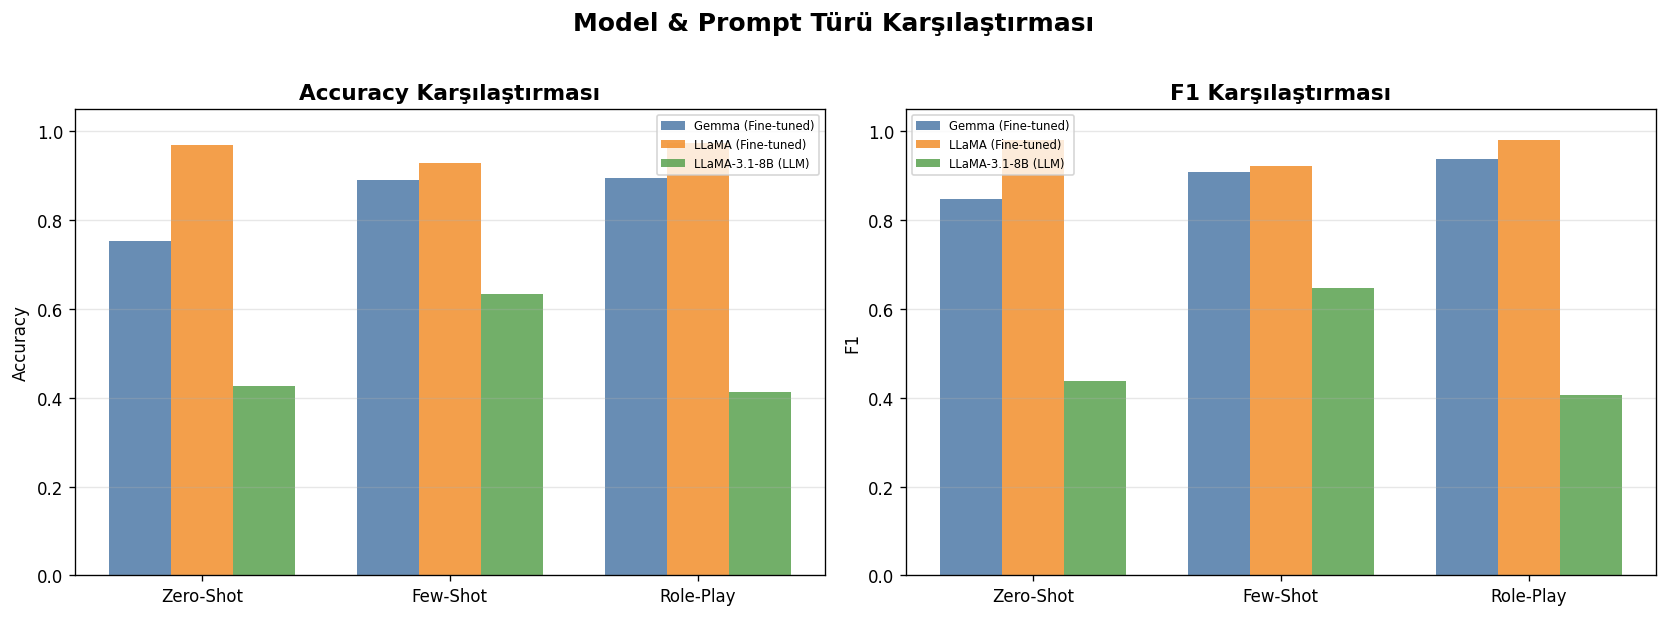

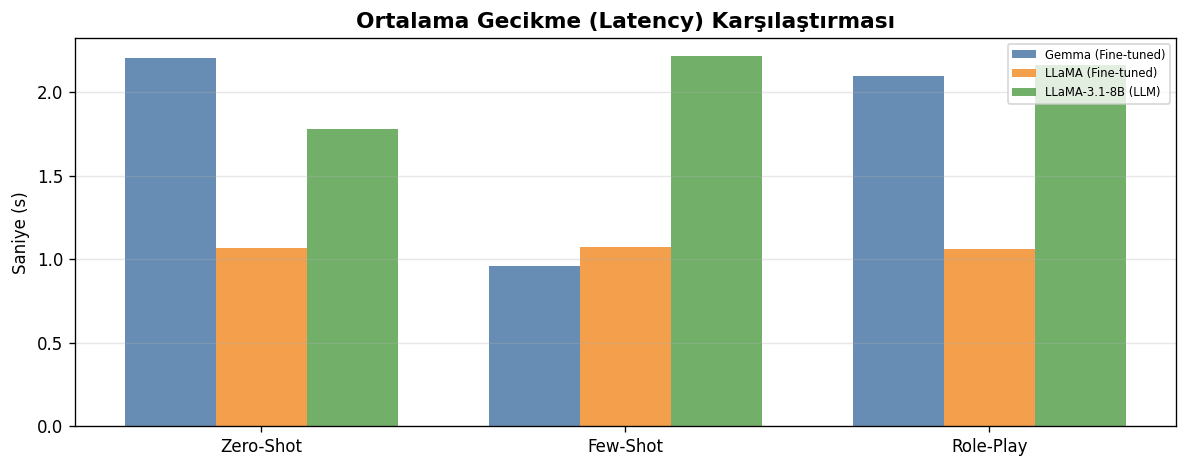


✅ Grafikler Drive'a kaydedildi.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from google.colab import drive
import shutil

matplotlib.rcParams['figure.dpi'] = 120

# Drive'dan yükle
drive.mount('/content/drive', force_remount=False)
shutil.copy("/content/drive/MyDrive/final_results.csv", "final_results.csv")

df_all = pd.read_csv("final_results.csv")

print("=" * 70)
print("📊 TÜM MODELLER — KARŞILAŞTIRMA TABLOSU")
print("=" * 70)
print(df_all.to_markdown(index=False))

# ================================================
# GÖRSEL: Accuracy & F1
# ================================================
prompts = ["zero_shot", "few_shot", "role_play"]
models  = df_all["Model"].unique()
x       = range(len(prompts))
width   = 0.25

color_list = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2"]
colors = {m: color_list[i % len(color_list)] for i, m in enumerate(models)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, metric in enumerate(["Accuracy", "F1"]):
    ax = axes[ax_idx]
    for i, m in enumerate(models):
        vals = []
        for p in prompts:
            v = df_all[(df_all["Model"] == m) & (df_all["Prompt"] == p)][metric].values
            vals.append(float(v[0]) if len(v) > 0 else 0)
        offset = (i - len(models) / 2 + 0.5) * width
        ax.bar([xi + offset for xi in x], vals, width,
               label=m, color=colors[m], alpha=0.85)

    ax.set_title(f"{metric} Karşılaştırması", fontsize=13, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(["Zero-Shot", "Few-Shot", "Role-Play"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Model & Prompt Türü Karşılaştırması", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_chart.png", bbox_inches='tight')
plt.show()

# ================================================
# GÖRSEL: Latency
# ================================================
fig2, ax2 = plt.subplots(figsize=(10, 4))
for i, m in enumerate(models):
    vals = []
    for p in prompts:
        v = df_all[(df_all["Model"] == m) & (df_all["Prompt"] == p)]["Avg Latency (s)"].values
        vals.append(float(v[0]) if len(v) > 0 else 0)
    offset = (i - len(models) / 2 + 0.5) * width
    ax2.bar([xi + offset for xi in x], vals, width,
            label=m, color=colors[m], alpha=0.85)

ax2.set_title("Ortalama Gecikme (Latency) Karşılaştırması", fontsize=13, fontweight='bold')
ax2.set_xticks(list(x))
ax2.set_xticklabels(["Zero-Shot", "Few-Shot", "Role-Play"])
ax2.set_ylabel("Saniye (s)")
ax2.legend(fontsize=7)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("latency_chart.png", bbox_inches='tight')
plt.show()

# Drive'a kaydet
shutil.copy("results_chart.png", "/content/drive/MyDrive/results_chart.png")
shutil.copy("latency_chart.png", "/content/drive/MyDrive/latency_chart.png")
print("\n✅ Grafikler Drive'a kaydedildi.")